In [1]:
import os
import sys
project_root = os.path.dirname(os.path.abspath('.'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
__package__ = 'rampa'

from rampa.query.duckdb_tools import DataManager, ArcGISQuery

In [2]:
import osmnx as ox
import pandas as pd
import geopandas as gpd
from rampa.routing.route import Network

# Layers

When a database connection is not provided, DataManager behaves like Data_Collection

In [ ]:
dmanager = DataManager(json_file=project_root +'/Users/mherrero/Documents/madrid_open_data/rampa/data/urls.json', populate=True)
dmanager.download_data()

But if we provide a database, we can populate it

In [4]:
dmanager_db = DataManager(json_file=project_root + '/rampa/data/urls.json', 
                          db_connection=project_root + '/rampa/data/prueba.db', 
                          populate=True)

INFO:rampa.query.arcgis_tools:Loading URL dictionary from JSON file: /Users/mherrero/Documents/madrid_open_data/rampa/data/urls.json
INFO:rampa.query.duckdb_tools:Creating collection of layers from URL dictionary.
  0%|          | 0/87 [00:00<?, ?it/s]INFO:rampa.query.arcgis_tools:Creating FeatureLayer from URL https://sigma.madrid.es/hosted/rest/services/GEOPORTAL/AREAS_ACTIVIDADES_PARA_MAYORES/MapServer/0
INFO:rampa.query.duckdb_tools:Stored layer AREAS_ACTIVIDADES_PARA_MAYORES in database with 305 records.
  1%|          | 1/87 [00:12<18:06, 12.63s/it]INFO:rampa.query.arcgis_tools:Creating FeatureLayer from URL https://sigma.madrid.es/hosted/rest/services/GEOPORTAL/AREAS_ACTIVIDADES_PARA_MAYORES/MapServer/1
INFO:rampa.query.duckdb_tools:Stored layer EJERCICIOS_PARA_MAYORES in database with 200 records.
  2%|▏         | 2/87 [00:38<28:37, 20.20s/it]INFO:rampa.query.arcgis_tools:Creating FeatureLayer from URL https://sigma.madrid.es/hosted/rest/services/GEOPORTAL/ASEOS_PUBLICOS/MapSer

Alternatively, if the database already exist, we can just load the layers onto the manager

In [3]:
dmanager_read = DataManager(json_file=project_root + '/rampa/data/urls.json', 
                          db_connection=project_root + '/rampa/data/prueba.db', 
                          populate=False) 

INFO:rampa.query.arcgis_tools:Loading URL dictionary from JSON file: /Users/mherrero/Documents/madrid_open_data/rampa/data/urls.json


By default, the data is kept in the database and brought only to memory when queried

In [4]:
print(len(dmanager_read.data))
layer = dmanager_read.get_layer_data('AREAS_ACTIVIDADES_PARA_MAYORES')
print(len(dmanager_read.data))

0


INFO:rampa.query.duckdb_tools:Loaded layer AREAS_ACTIVIDADES_PARA_MAYORES from database: 305 records


1


We can load all layers in memory by

In [5]:
dmanager_read.load_all_layers()
print(len(dmanager_read.data))

  0%|          | 0/87 [00:00<?, ?it/s]INFO:rampa.query.duckdb_tools:Loaded layer EJERCICIOS_PARA_MAYORES from database: 200 records
INFO:rampa.query.duckdb_tools:Loaded layer ASEOS_PUBLICOS from database: 118 records
INFO:rampa.query.duckdb_tools:Loaded layer CUIDAR_A_QUIENES_NOS_CUIDAN from database: 21 records
INFO:rampa.query.duckdb_tools:Loaded layer JUNTOS_CONTRA_LA_SOLEDAD from database: 20 records
INFO:rampa.query.duckdb_tools:Loaded layer NOMBRES_DE_BARRIOS from database: 131 records
INFO:rampa.query.duckdb_tools:Loaded layer SECCIONES_CENSALES from database: 2462 records
INFO:rampa.query.duckdb_tools:Loaded layer DENSIDAD_POBLACION from database: 2450 records
INFO:rampa.query.duckdb_tools:Loaded layer EDAD_PROMEDIO from database: 2450 records
INFO:rampa.query.duckdb_tools:Loaded layer PROPORCION_JUVENTUD from database: 2450 records
INFO:rampa.query.duckdb_tools:Loaded layer PROPORCION_ENVEJECIMIENTO from database: 2450 records
INFO:rampa.query.duckdb_tools:Loaded layer PROPORC

87


# Routing

We can start by downloading the graph defined by a boundary. The optional argument db allows us to store the graph using duckdb.

In [6]:
lay = ArcGISQuery('https://sigma.madrid.es/hosted/rest/services/CARTOGRAFIA/ANCHO_MEDIO_VIARIO/MapServer/0')
lay.create_layer()
aceras = lay.query(where="1=1")
madrid = ox.geocoder.geocode_to_gdf('R5326784', by_osmid=True)
net = Network(madrid, db=project_root + '/rampa/data/grafo.db', db_alt=project_root + '/rampa/data/grafo_alt.db', aceras=aceras, row='Ancho_medio', store=True)

INFO:rampa.query.arcgis_tools:Creating FeatureLayer from URL https://sigma.madrid.es/hosted/rest/services/CARTOGRAFIA/ANCHO_MEDIO_VIARIO/MapServer/0


Generating contraction hierarchies with 1 threads.
Setting CH node vector of size 165387
Setting CH edge vector of size 495988
Range graph removed 501892 edges of 991976
. 10% . 20% . 30% . 40% . 50% . 60% . 70% . 80% . 90% . 100%


/Users/mherrero/Documents/madrid_open_data/rampa/routing/route.py:150: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.edges_alt[self.row] = self.edges_alt[self.row].fillna(0)


Generating contraction hierarchies with 1 threads.
Setting CH node vector of size 165387
Setting CH edge vector of size 495988
Range graph removed 501892 edges of 991976
. 10% . 20% . 30% . 40% . 50% . 60% . 70% . 80% . 90% . 100%
Storing network in DuckDB
Storing network in DuckDB


After it's saved into the DB, we can simply load it from there, without need to download it again

In [3]:
net_db = Network(db=project_root + '/rampa/data/grafo.db', db_alt=project_root + '/rampa/data/grafo_alt.db')

Generating contraction hierarchies with 1 threads.
Setting CH node vector of size 165387
Setting CH edge vector of size 495988
Range graph removed 501892 edges of 991976
. 10% . 20% . 30% . 40% . 50% . 60% . 70% . 80% . 90% . 100%
Generating contraction hierarchies with 1 threads.
Setting CH node vector of size 165387
Setting CH edge vector of size 495988
Range graph removed 501892 edges of 991976
. 10% . 20% . 30% . 40% . 50% . 60% . 70% . 80% . 90% . 100%


Nodes and edges are stored in their corresponding dataframes

In [5]:
net_db.nodes

,x,y
index,,
171946,-3.684443,40.421247
171951,-3.688989,40.417360
171952,-3.688980,40.414991
171953,-3.688901,40.412775
20952893,-3.597241,40.430465
...,...,...
13069374949,-3.759205,40.401607
13069761885,-3.688659,40.477519
13069761886,-3.688402,40.477475


In [5]:
net.edges_alt

,from,to,distance,geometry,Ancho_medio,accesibility,alt_distance
0,171946,11218044065,3.817747,"LINESTRING (-3.68444 40.42125, -3.68444 40.42128)",8.455519,1,38.177473
1,171946,1209330272,33.546989,"LINESTRING (-3.68444 40.42125, -3.68419 40.42108)",8.455519,1,335.469885
2,171946,3280496563,28.937732,"LINESTRING (-3.68444 40.42125, -3.68451 40.42099)",8.455519,1,289.377317
3,171951,26486638,125.173331,"LINESTRING (-3.68899 40.41736, -3.69047 40.41733)",3.801702,1,1251.733310
4,171951,1209331009,18.732956,"LINESTRING (-3.68899 40.41736, -3.68885 40.41749)",15.204084,1,187.329562
...,...,...,...,...,...,...,...
495983,13069761888,13069761885,18.114956,"LINESTRING (-3.68862 40.47768, -3.68866 40.47752)",0.000000,0,18.114956
495984,13069761888,13069761889,22.058976,"LINESTRING (-3.68862 40.47768, -3.68836 40.47764)",0.000000,0,22.058976
495985,13069761889,5676730807,70.251765,"LINESTRING (-3.68836 40.47764, -3.6882 40.47826)",0.000000,0,70.251765
495986,13069761889,13069761888,22.058976,"LINESTRING (-3.68836 40.47764, -3.68862 40.47768)",0.000000,0,22.058976


The routing engine works by invoking route or route_gdf. The first returns a list of nodes, the second a gdf.

In [7]:
coord1 = (-3.703790, 40.416775)  # Example coordinates for Madrid in (longitude, latitude) format.
coord2 = (-3.72, 40.416775)

In [9]:
ruta = net.route_gdf(coord1, coord2, alternate=False)
ruta_alt = net.route_gdf(coord1, coord2, alternate=True)

<Axes: >

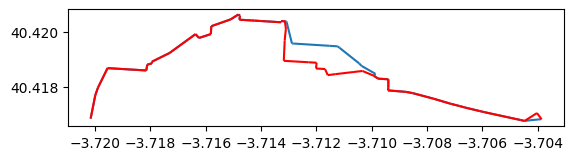

In [13]:
ax = ruta.plot()
ruta_alt.plot(ax=ax, color='red')

In [22]:
print(ruta['distance'].sum())
print(ruta_alt['distance'].sum())

1916.3985519527455
6318.440578934675


In [12]:
layer = dmanager_read.get_layer_data('ACCESIBILIDAD_ACERAS_2021')

In [11]:
dmanager_read.layers['ACCESIBILIDAD_ACERAS_2021'].url

'https://sigma.madrid.es/hosted/rest/services/OBRAS/ACCESIBILIDAD_ACERAS_2021/MapServer/0'

In [14]:
layer[layer['DISTRITO']=='10. LATINA']

,DISTRITO,CALLE,ACTUACIÓN,SUP_Calzad,SUP_Acera,PP_N,PP_R,Estado,OBJECTID
53,10. LATINA,Calle Ocaña,ACERA Y CALZADA,265.10,669.90,2,2.0,3.0,55
69,10. LATINA,Calle Aramis cv Calle Manuel Muiño,"ACERA, CALZADA Y TALUD",1591.26,1802.59,2,6.0,3.0,71
70,10. LATINA,Calle Aramis,ACERA Y CALZADA,114.16,576.80,2,2.0,3.0,72
72,10. LATINA,Calle Los Yébenes,Acera,0.00,2226.30,2,1.0,3.0,74
180,10. LATINA,Calle Camarena,Acera y calzada,55.00,353.00,0,0.0,3.0,182
181,10. LATINA,Calle Concejal Francisco José Jiménez Martín,ACERA,335.50,1947.15,0,36.0,3.0,183
182,10. LATINA,Calle Aldeanueva de la Vera,ACERA Y CALZADA,1183.00,654.00,0,7.0,3.0,184
183,10. LATINA,Avenida de las Águilas,ACERA,34.00,219.00,0,5.0,3.0,185
196,10. LATINA,Calle Maqueda,Acera y calzada,232.50,2014.00,0,4.0,3.0,198
197,10. LATINA,Calle Seseña,Acera y calzada,393.00,2765.00,8,14.0,3.0,199


In [7]:
dmanager_read.layers.keys()

dict_keys(['AREAS_ACTIVIDADES_PARA_MAYORES', 'EJERCICIOS_PARA_MAYORES', 'ASEOS_PUBLICOS', 'CUIDAR_A_QUIENES_NOS_CUIDAN', 'JUNTOS_CONTRA_LA_SOLEDAD', 'NOMBRES_DE_BARRIOS', 'SECCIONES_CENSALES', 'DENSIDAD_POBLACION', 'EDAD_PROMEDIO', 'PROPORCION_JUVENTUD', 'PROPORCION_ENVEJECIMIENTO', 'PROPORCION_SOBREENVEJECIMIENTO', 'INDICE_ENVEJECIMIENTO', 'INDICE_JUVENTUD', 'INDICE_DEPENDENCIA', 'INDICE_ESTRUCTURA_POBLACION_ACTIVA', 'INDICE_REEMPLAZO_POBLACION_ACTIVA', 'RAZON_PROGRESIVIDAD_DEMOGRAFICA', 'TOTAL_AMBOS_SEXOS', 'POBLACION_0_4_ANOS', 'POBLACION_5_9_ANOS', 'POBLACION_10_14_ANOS', 'POBLACION_15_19_ANOS', 'POBLACION_20_24_ANOS', 'POBLACION_25_29_ANOS', 'POBLACION_30_34_ANOS', 'POBLACION_35_39_ANOS', 'POBLACION_40_44_ANOS', 'POBLACION_45_49_ANOS', 'POBLACION_50_54_ANOS', 'POBLACION_55_59_ANOS', 'POBLACION_60_64_ANOS', 'POBLACION_65_69_ANOS', 'POBLACION_70_74_ANOS', 'POBLACION_75_79_ANOS', 'POBLACION_80_84_ANOS', 'POBLACION_85_89_ANOS', 'POBLACION_90_94_ANOS', 'POBLACION_95_99_ANOS', 'POBLACIO

INFO:rampa.query.arcgis_tools:Creating FeatureLayer from URL https://sigma.madrid.es/hosted/rest/services/CARTOGRAFIA/ANCHO_MEDIO_VIARIO/MapServer/0


In [6]:
net_db.set_alternate_network(aceras, 'Ancho_medio')

/Users/mherrero/Documents/madrid_open_data/rampa/routing/route.py:126: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.edges_alt[row] = self.edges_alt[row].fillna(0)


Generating contraction hierarchies with 1 threads.
Setting CH node vector of size 165387
Setting CH edge vector of size 495988
Range graph removed 501892 edges of 991976
. 10% . 20% . 30% . 40% . 50% . 60% . 70% . 80% . 90% . 100%


In [12]:
ruta_alt.to_json()

'{"type": "FeatureCollection", "features": [{"id": "464866", "type": "Feature", "properties": {"from": 12289775102, "to": 5308255544, "distance": 28.167621595813678}, "geometry": {"type": "LineString", "coordinates": [[-3.7038577, 40.4168405], [-3.7040231, 40.4170603]]}}, {"id": "289881", "type": "Feature", "properties": {"from": 5308255544, "to": 12289772637, "distance": 49.94436158618693}, "geometry": {"type": "LineString", "coordinates": [[-3.7040231, 40.4170603], [-3.7044732, 40.4167752]]}}, {"id": "464838", "type": "Feature", "properties": {"from": 12289772637, "to": 12289772644, "distance": 12.211339633211615}, "geometry": {"type": "LineString", "coordinates": [[-3.7044732, 40.4167752], [-3.7046109, 40.4168079]]}}, {"id": "464851", "type": "Feature", "properties": {"from": 12289772644, "to": 5302261816, "distance": 114.77342878458276}, "geometry": {"type": "LineString", "coordinates": [[-3.7046109, 40.4168079], [-3.7059143, 40.4170909]]}}, {"id": "289603", "type": "Feature", "pro